In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Extraction (SQL)
### 1.1. Load the raw dataset

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/Dataset/Hospital readmission/diabetic_data.csv')
df.shape

(101766, 50)

In [ ]:
print(df.columns.tolist())
df.info()

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------     

### 1.2. Split into 4 relational tables

In [ ]:
# 1. PATIENTS table — one row per unique patient (static attributes)
# drop_duplicates keeps the FIRST occurrence of each patient_nbr,
# since the same patient can have multiple hospital encounters
patients = df[['patient_nbr', 'race', 'gender', 'age', 'weight']] \
    .drop_duplicates(subset='patient_nbr') \
    .reset_index(drop=True)

# 2. ENCOUNTERS table — one row per hospital visit (admission details + target variable)
encounters = df[['encounter_id', 'patient_nbr', 'admission_type_id',
                  'discharge_disposition_id', 'admission_source_id',
                  'time_in_hospital', 'payer_code', 'medical_specialty',
                  'readmitted']].reset_index(drop=True)

# 3. DIAGNOSES table — diagnosis codes per encounter
diagnoses = df[['encounter_id', 'diag_1', 'diag_2', 'diag_3',
                 'number_diagnoses']].reset_index(drop=True)

# 4. PROCEDURES_MEDS table — labs, procedures, and FULL medication info per encounter
medication_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
                    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                    'miglitol', 'troglitazone', 'tolazamide', 'examide',
                    'citoglipton', 'insulin', 'glyburide-metformin',
                    'glipizide-metformin', 'glimepiride-pioglitazone',
                    'metformin-rosiglitazone', 'metformin-pioglitazone']

procedures_meds = df[['encounter_id', 'num_lab_procedures', 'num_procedures',
                       'num_medications', 'number_outpatient', 'number_emergency',
                       'number_inpatient', 'diabetesMed', 'change',
                       'A1Cresult', 'max_glu_serum'] + medication_cols].reset_index(drop=True)

print("\npatients:", patients.shape)
print("encounters:", encounters.shape)
print("diagnoses:", diagnoses.shape)
print("procedures_meds:", procedures_meds.shape)



patients: (71518, 5)
encounters: (101766, 9)
diagnoses: (101766, 5)
procedures_meds: (101766, 34)


### 1.3. Load all 4 tables into SQLite database

In [ ]:
conn = sqlite3.connect('hospital_readmission.db')

patients.to_sql('patients', conn, if_exists='replace', index=False)
encounters.to_sql('encounters', conn, if_exists='replace', index=False)
diagnoses.to_sql('diagnoses', conn, if_exists='replace', index=False)
procedures_meds.to_sql('procedures_meds', conn, if_exists='replace', index=False)

print("\nAll 4 tables loaded into hospital_readmission.db")

# Verify tables exist in the database
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print("Tables in database:", cursor.fetchall())



All 4 tables loaded into hospital_readmission.db
Tables in database: [('patients',), ('encounters',), ('diagnoses',), ('procedures_meds',)]


### 1.4. JOIN — reconstruct one usable dataset from the 4 tables

In [ ]:
query = """
SELECT
    e.encounter_id, e.patient_nbr,
    p.race, p.gender, p.age, p.weight,
    e.admission_type_id, e.discharge_disposition_id, e.admission_source_id,
    e.time_in_hospital, e.payer_code, e.medical_specialty,
    d.diag_1, d.diag_2, d.diag_3, d.number_diagnoses,
    pm.*,
    e.readmitted
FROM encounters e
JOIN patients p ON e.patient_nbr = p.patient_nbr
JOIN diagnoses d ON e.encounter_id = d.encounter_id
JOIN procedures_meds pm ON e.encounter_id = pm.encounter_id
"""

joined_df = pd.read_sql_query(query, conn)


joined_df = joined_df.loc[:, ~joined_df.columns.duplicated()]

print("\nJoined dataset shape:", joined_df.shape)
joined_df.head()


Joined dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,No,No,Up,No,No,No,No,No,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,No,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,No,No,Up,No,No,No,No,No,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,No,Steady,No,No,No,No,No,NO


## 2. Preprocessing

### 2.1. Missing value handling

In [ ]:
# Replace '?' with actual NaN so pandas can properly detect all missingness
joined_df_clean_check = joined_df.replace('?', np.nan)

# Calculate missingness per column
missing_summary = pd.DataFrame({
    'missing_count': joined_df_clean_check.isnull().sum(),
    'missing_percent': (joined_df_clean_check.isnull().sum() / len(joined_df_clean_check) * 100).round(2)
})

missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_percent', ascending=False)

print(missing_summary)

                   missing_count  missing_percent
weight                     98562            96.85
max_glu_serum              96420            94.75
A1Cresult                  84748            83.28
medical_specialty          49949            49.08
payer_code                 40256            39.56
race                        2367             2.33
diag_3                      1423             1.40
diag_2                       358             0.35
diag_1                        21             0.02


In [ ]:
df_clean = joined_df_clean_check.copy()

df_clean = df_clean.drop(columns=['weight'])
df_clean['max_glu_serum'] = df_clean['max_glu_serum'].fillna('NotTested')
df_clean['A1Cresult'] = df_clean['A1Cresult'].fillna('NotTested')
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Unknown')
df_clean = df_clean.drop(columns=['payer_code'])
df_clean['race'] = df_clean['race'].fillna('Unknown')
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("Shape after cleaning:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())

Shape after cleaning: (101766, 48)
Remaining missing values: 0


### 2.2. ID-to-label mapping

In [ ]:
ids = pd.read_csv('/content/drive/My Drive/Dataset/Hospital readmission/IDS_mapping.csv')

discharge_start = ids[ids['admission_type_id'] == 'discharge_disposition_id'].index[0]
source_start = ids[ids['admission_type_id'] == 'admission_source_id'].index[0]

admission_type_map = ids.iloc[0:discharge_start-1].copy()
admission_type_map.columns = ['id', 'description']

discharge_map = ids.iloc[discharge_start+1:source_start-1].copy()
discharge_map.columns = ['id', 'description']

admission_source_map = ids.iloc[source_start+1:].copy()
admission_source_map.columns = ['id', 'description']

for table in [admission_type_map, discharge_map, admission_source_map]:
    table['id'] = pd.to_numeric(table['id'], errors='coerce')
    table.dropna(subset=['id'], inplace=True)
    table['id'] = table['id'].astype(int)

admission_type_dict = dict(zip(admission_type_map['id'], admission_type_map['description']))
discharge_dict = dict(zip(discharge_map['id'], discharge_map['description']))
source_dict = dict(zip(admission_source_map['id'], admission_source_map['description']))

# Fix whitespace issues in descriptions
for d in [admission_type_dict, discharge_dict, source_dict]:
    for k in d:
        if isinstance(d[k], str):
            d[k] = d[k].strip()

# Fix the NaN/NULL entry
discharge_dict[18] = 'Not Mapped'
source_dict[17] = 'Not Mapped'
admission_type_dict[6] = 'Not Mapped'


# Apply the mappings to create readable label columns


df_clean['admission_type_name'] = df_clean['admission_type_id'].map(admission_type_dict)
df_clean['discharge_disposition_name'] = df_clean['discharge_disposition_id'].map(discharge_dict)
df_clean['admission_source_name'] = df_clean['admission_source_id'].map(source_dict)

# Check: any unmapped IDs left as missing?
print("\nUnmapped values check:")
print(df_clean[['admission_type_name','discharge_disposition_name','admission_source_name']].isnull().sum())


print("\nFinal shape:", df_clean.shape)
df_clean.head()


Unmapped values check:
admission_type_name           0
discharge_disposition_name    0
admission_source_name         0
dtype: int64

Final shape: (101766, 51)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,readmitted,admission_type_name,discharge_disposition_name,admission_source_name
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,NO,Not Mapped,Not Mapped,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,Up,No,No,No,No,No,>30,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,NO,Emergency,Discharged to home,Emergency Room
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,Up,No,No,No,No,No,NO,Emergency,Discharged to home,Emergency Room
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,Steady,No,No,No,No,No,NO,Emergency,Discharged to home,Emergency Room


In [ ]:
print("=== Admission Type Mapping ===")
display(pd.DataFrame(list(admission_type_dict.items()), columns=['id', 'description']).sort_values('id'))

print("=== Discharge Disposition Mapping ===")
display(pd.DataFrame(list(discharge_dict.items()), columns=['id', 'description']).sort_values('id'))

print("=== Admission Source Mapping ===")
display(pd.DataFrame(list(source_dict.items()), columns=['id', 'description']).sort_values('id'))

=== Admission Type Mapping ===


,id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,Not Mapped
6,7,Trauma Center
7,8,Not Mapped


=== Discharge Disposition Mapping ===


,id,description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...
5,6,Discharged/transferred to home with home healt...
6,7,Left AMA
7,8,Discharged/transferred to home under care of H...
8,9,Admitted as an inpatient to this hospital
9,10,Neonate discharged to another hospital for neo...


=== Admission Source Mapping ===


,id,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)
5,6,Transfer from another health care facility
6,7,Emergency Room
7,8,Court/Law Enforcement
8,9,Not Available
9,10,Transfer from critial access hospital


### 2.3. Clinical cohort filtering

In [ ]:
# Inspect discharge dispositions related to death or hospice care
death_hospice_ids = {
    11: 'Expired',
    19: 'Expired at home. Medicaid only, hospice.',
    20: 'Expired in a medical facility. Medicaid only, hospice.',
    21: 'Expired, place unknown. Medicaid only, hospice.',
    13: 'Hospice / home',
    14: 'Hospice / medical facility'
}

print("Checking discharge_disposition_name value counts for death/hospice related categories:\n")
print(df_clean['discharge_disposition_name'].value_counts().loc[
    df_clean['discharge_disposition_name'].value_counts().index.isin(death_hospice_ids.values())
])

# confirm 'readmitted' status for these rows
print("\nreadmitted values among Expired patients (should logically be NO):")
print(df_clean[df_clean['discharge_disposition_id'].isin([11,19,20,21])]['readmitted'].value_counts())

print("\nTotal rows before removal:", df_clean.shape[0])

Checking discharge_disposition_name value counts for death/hospice related categories:

discharge_disposition_name
Expired                                                   1642
Hospice / home                                             399
Hospice / medical facility                                 372
Expired at home. Medicaid only, hospice.                     8
Expired in a medical facility. Medicaid only, hospice.       2
Name: count, dtype: int64

readmitted values among Expired patients (should logically be NO):
readmitted
NO    1652
Name: count, dtype: int64

Total rows before removal: 101766


In [ ]:
# Drop rows where patient expired or was discharged to hospice —
exclude_ids = [11, 19, 20, 21, 13, 14]  # Expired (4 variants) + Hospice (2 variants)

df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(exclude_ids)].reset_index(drop=True)

print("Total rows after removal:", df_clean.shape[0])
print("Rows removed:", 101766 - df_clean.shape[0])

Total rows after removal: 99343
Rows removed: 2423


 Expired and hospice discharge encounters were excluded before modeling because these patients were not part of the population at risk for future hospital readmission. Their readmitted = NO status reflects mortality or end-of-life care decisions, not successful recovery after discharge. Retaining these records would introduce misleading signal into the negative class. Excluding these 2,423 encounters (~2.4% of the dataset) produces a clinically more appropriate cohort for 30-day hospital readmission prediction.

In [ ]:
# Drop raw ID columns now that we have their readable '_name' counterparts.
df_clean = df_clean.drop(columns=['admission_type_id', 'discharge_disposition_id', 'admission_source_id'])

print("Shape after dropping redundant ID columns:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Shape after dropping redundant ID columns: (99343, 48)

Remaining columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'time_in_hospital', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diabetesMed', 'change', 'A1Cresult', 'max_glu_serum', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'readmitted', 'admission_type_name', 'discharge_disposition_name', 'admission_source_name']


### 2.4. Data Integrity Checks

In [ ]:
# Check for duplicate rows
print("\nExact duplicate rows:", df_clean.duplicated().sum())

# Check data types
print("\nData types overview:")
print(df_clean.dtypes.value_counts())


Exact duplicate rows: 0

Data types overview:
object    38
int64     10
Name: count, dtype: int64


In [ ]:
# Data type verification
print("Numeric (int64) columns:")
print(df_clean.select_dtypes(include='int64').columns.tolist())

print("\nObject (categorical/text) columns:")
print(df_clean.select_dtypes(include='object').columns.tolist())

Numeric (int64) columns:
['encounter_id', 'patient_nbr', 'time_in_hospital', 'number_diagnoses', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient']

Object (categorical/text) columns:
['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'diabetesMed', 'change', 'A1Cresult', 'max_glu_serum', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'readmitted', 'admission_type_name', 'discharge_disposition_name', 'admission_source_name']


In [ ]:
# Summary statistics for all columns (numeric + categorical)
summary = df_clean.describe(include='all').T
print(summary)

                              count unique                 top   freq  \
encounter_id                99343.0    NaN                 NaN    NaN   
patient_nbr                 99343.0    NaN                 NaN    NaN   
race                          99343      6           Caucasian  74168   
gender                        99343      3              Female  53455   
age                           99343     10             [70-80)  25376   
time_in_hospital            99343.0    NaN                 NaN    NaN   
medical_specialty             99343     73             Unknown  48616   
diag_1                        99343    716                 428   6663   
diag_2                        99343    748                 276   6589   
diag_3                        99343    787                 250  11466   
number_diagnoses            99343.0    NaN                 NaN    NaN   
num_lab_procedures          99343.0    NaN                 NaN    NaN   
num_procedures              99343.0    NaN         

The cleaned dataset contains 99,343 hospital encounters and represents predominantly older diabetic patients, with the 70–80 age group being the most common. Most admissions were emergency admissions through the emergency room, and the majority of patients were discharged to home.

Patients generally have multiple health conditions and are taking several medications, indicating a clinically complex population that may have a higher risk of readmission. Laboratory tests such as A1C and serum glucose were frequently recorded as NotTested, suggesting that test availability itself may carry useful clinical information.

The target analysis shows that 11.4% of patients were readmitted within 30 days, while 88.6% were not, indicating a moderately imbalanced classification problem that will be considered during the modeling stage.

### 2.5. Near-Zero-Variance Column Removal

In [ ]:
# Check dominance percentage for each medication column,
# to identify near-zero-variance columns before deciding what to drop
medication_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
                    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                    'miglitol', 'troglitazone', 'tolazamide', 'examide',
                    'citoglipton', 'insulin', 'glyburide-metformin',
                    'glipizide-metformin', 'glimepiride-pioglitazone',
                    'metformin-rosiglitazone', 'metformin-pioglitazone']

results = []
for col in medication_cols:
    top_freq = df_clean[col].value_counts(normalize=True).iloc[0]
    top_val = df_clean[col].value_counts().index[0]
    results.append({'column': col, 'dominant_value': top_val, 'dominance_pct': round(top_freq*100, 3)})

dominance_df = pd.DataFrame(results).sort_values('dominance_pct', ascending=False)
print(dominance_df.to_string(index=False))

# Flag columns above 99% dominance — candidates for dropping
print("\nColumns with >99% dominance (near-zero variance):")
print(dominance_df[dominance_df['dominance_pct'] > 99]['column'].tolist())

                  column dominant_value  dominance_pct
             citoglipton             No        100.000
                 examide             No        100.000
           acetohexamide             No         99.999
  metformin-pioglitazone             No         99.999
glimepiride-pioglitazone             No         99.999
 metformin-rosiglitazone             No         99.998
            troglitazone             No         99.997
     glipizide-metformin             No         99.987
             tolbutamide             No         99.979
                miglitol             No         99.962
              tolazamide             No         99.961
          chlorpropamide             No         99.914
                acarbose             No         99.693
             nateglinide             No         99.306
     glyburide-metformin             No         99.297
             repaglinide             No         98.472
             glimepiride             No         94.844
          

In [ ]:
# Drop medication columns with >99% single-category dominance (near-zero variance).

near_zero_variance_cols = ['citoglipton', 'examide', 'acetohexamide',
                            'metformin-pioglitazone', 'glimepiride-pioglitazone',
                            'metformin-rosiglitazone', 'troglitazone',
                            'glipizide-metformin', 'tolbutamide', 'miglitol',
                            'tolazamide', 'chlorpropamide', 'acarbose',
                            'nateglinide', 'glyburide-metformin']

df_clean = df_clean.drop(columns=near_zero_variance_cols)

print("Shape after dropping near-zero-variance medication columns:", df_clean.shape)
print("Columns dropped:", len(near_zero_variance_cols))
print("\nRemaining medication-related columns:")
remaining_meds = ['metformin', 'repaglinide', 'glimepiride', 'glipizide',
                   'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
print(remaining_meds)

Shape after dropping near-zero-variance medication columns: (99343, 33)
Columns dropped: 15

Remaining medication-related columns:
['metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']


Near-zero-variance analysis identified 15 medication columns with more than 99% identical values (No). These features were removed because they provide minimal predictive information. The dataset was reduced to 99,343 rows and 34 clinically relevant features, resulting in a cleaner and more efficient modeling dataset.

## 3. EDA (Exploratory Data Analysis)

In [ ]:
# Create binary target for 30-day readmission
df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)

print("Original readmitted distribution:")
print(df_clean['readmitted'].value_counts())
print("\nBinary target distribution:")
print(df_clean['readmitted_30d'].value_counts())
print("\nClass balance (%):")
print(df_clean['readmitted_30d'].value_counts(normalize=True) * 100)

Original readmitted distribution:
readmitted
NO     52527
>30    35502
<30    11314
Name: count, dtype: int64

Binary target distribution:
readmitted_30d
0    88029
1    11314
Name: count, dtype: int64

Class balance (%):
readmitted_30d
0    88.611175
1    11.388825
Name: proportion, dtype: float64


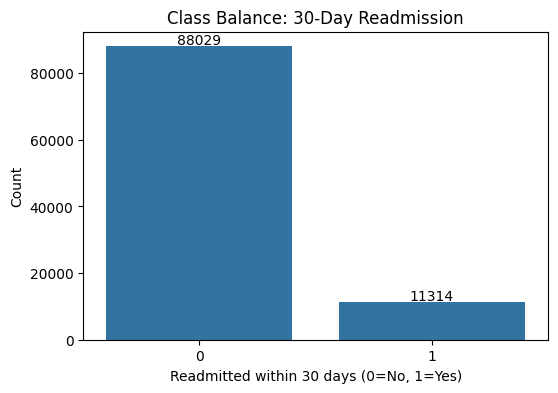

In [ ]:
# Class balance visualization
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted_30d', data=df_clean)
plt.title('Class Balance: 30-Day Readmission')
plt.xlabel('Readmitted within 30 days (0=No, 1=Yes)')
plt.ylabel('Count')
for i, v in enumerate(df_clean['readmitted_30d'].value_counts().sort_index()):
    plt.text(i, v + 500, str(v), ha='center')
plt.show()

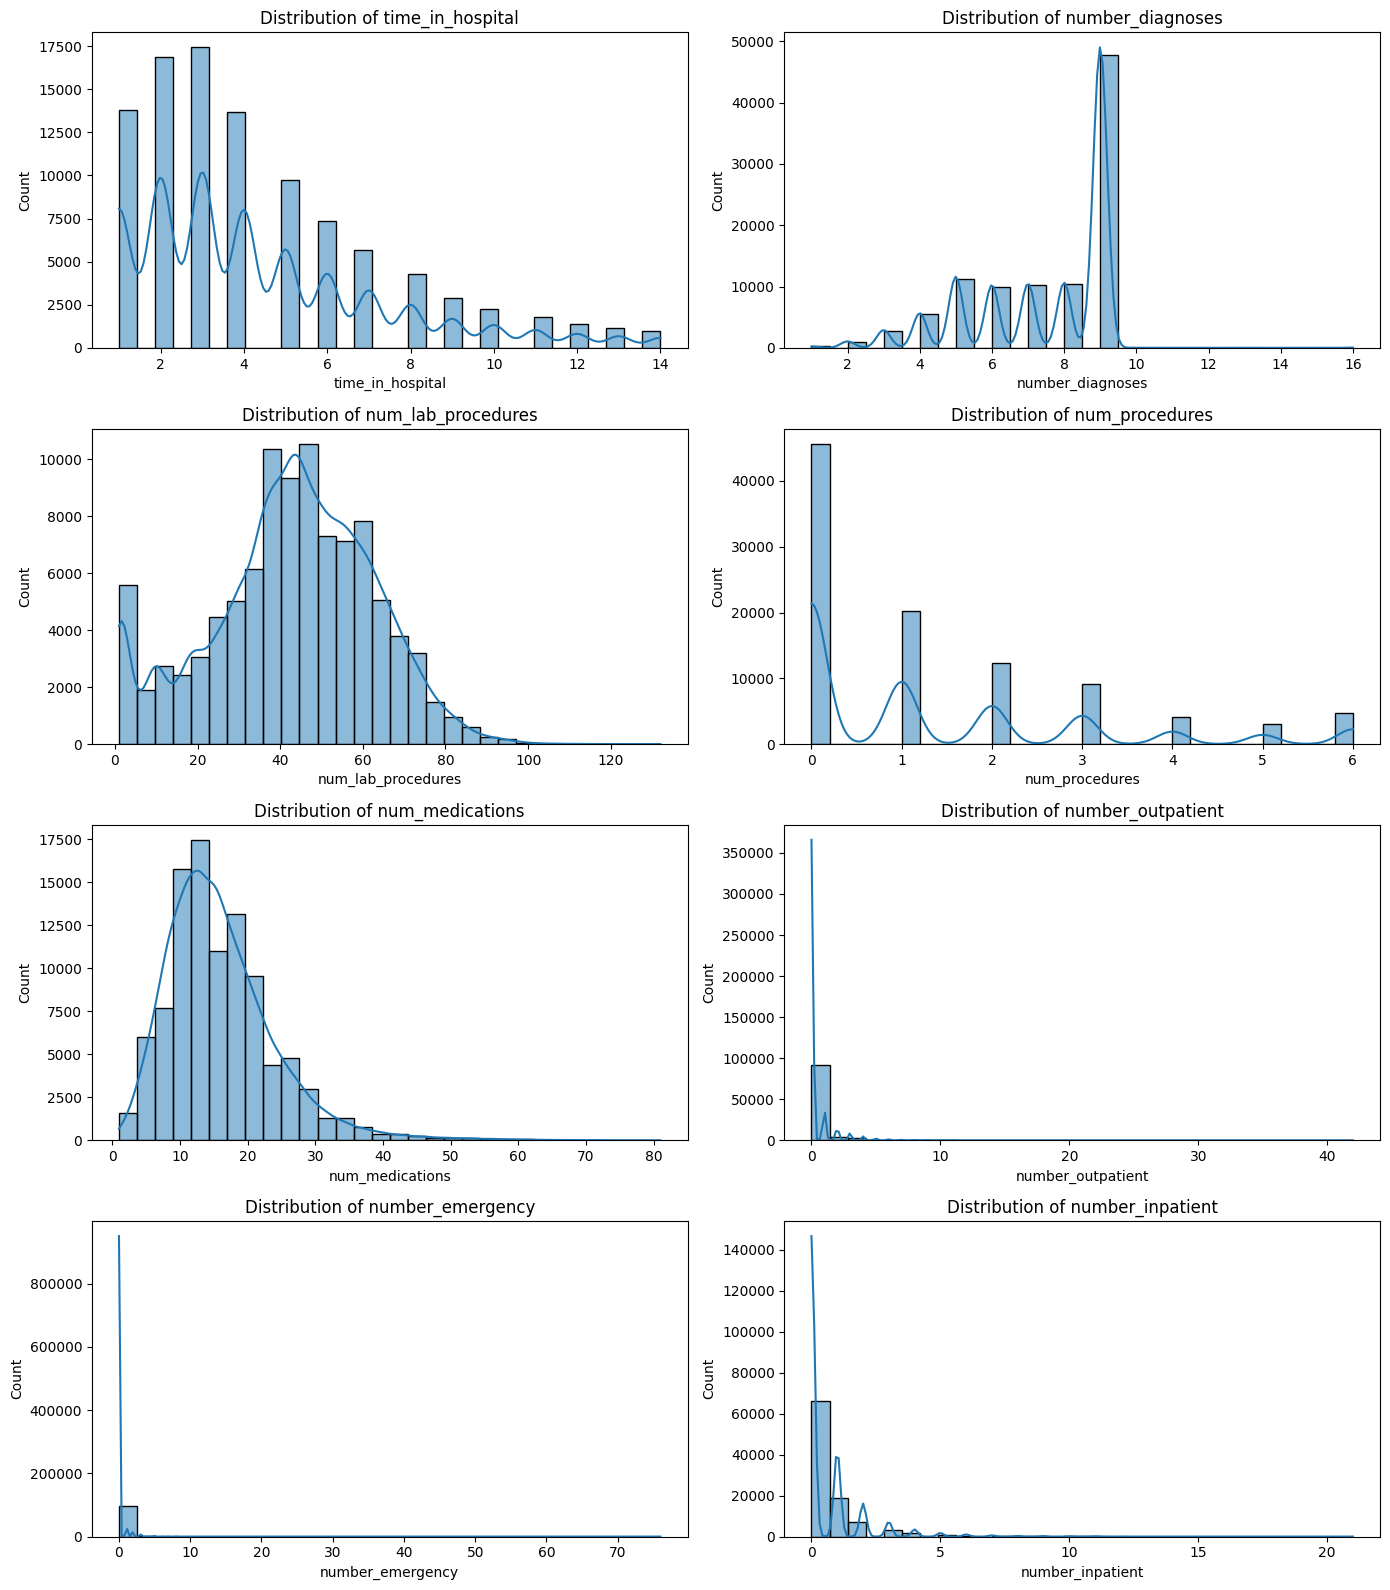

In [ ]:
# Univariate Analysis — Numeric Features
numeric_cols = ['time_in_hospital', 'number_diagnoses', 'num_lab_procedures',
                 'num_procedures', 'num_medications', 'number_outpatient',
                 'number_emergency', 'number_inpatient']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

The numeric variables show clinically reasonable distributions. **Hospital stay duration** is moderately right-skewed, with most patients staying **2–4 days**. **Laboratory procedures** and **medication counts** show meaningful variation across patients and are likely to be informative predictors. **Procedure counts** are strongly right-skewed, with most encounters involving **no procedures**, which is expected in routine hospital admissions. The previous healthcare utilization variables (`number_outpatient`, `number_emergency`, and `number_inpatient`) are **highly right-skewed**, with the majority of patients having **zero prior visits** and a small subset showing repeated healthcare utilization. Overall, the distributions appear plausible for a hospital readmission dataset and do not indicate major data quality issues.


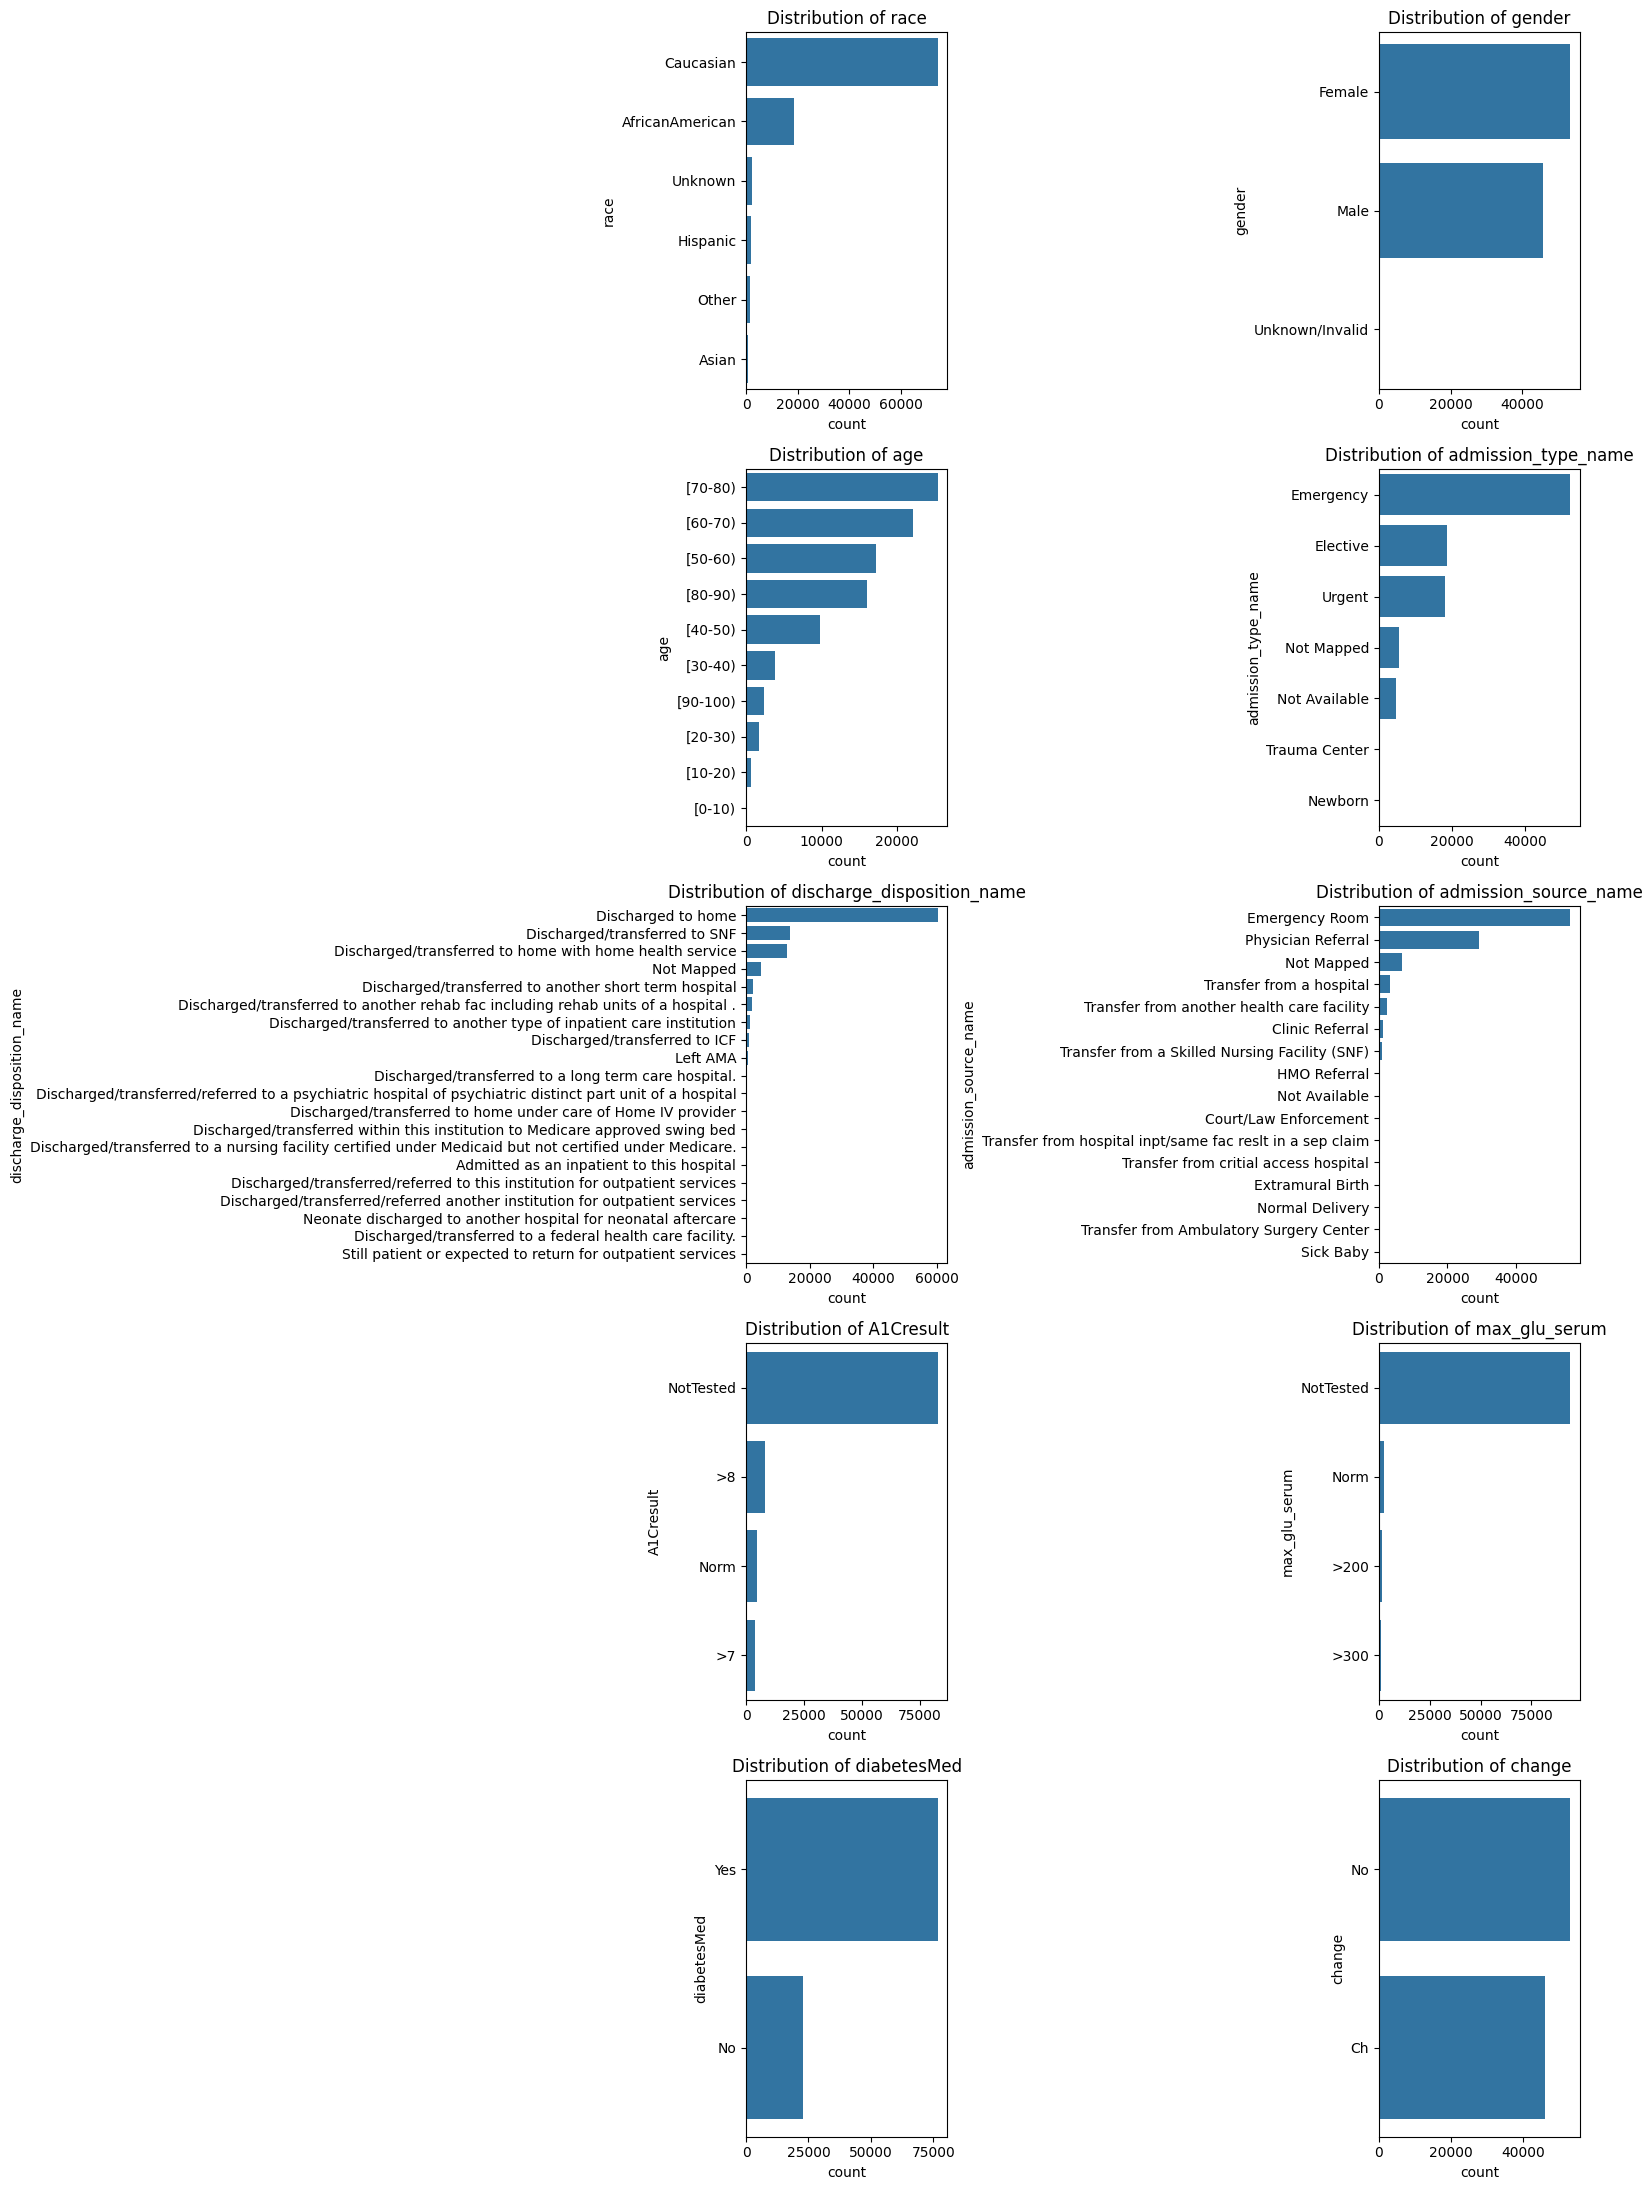

In [ ]:
# Univariate Analysis — Categorical Features
categorical_cols = ['race', 'gender', 'age', 'admission_type_name',
                     'discharge_disposition_name', 'admission_source_name',
                     'A1Cresult', 'max_glu_serum', 'diabetesMed', 'change']

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df_clean[col].value_counts().index
    sns.countplot(y=col, data=df_clean, order=order, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

The categorical feature distributions show that the dataset is dominated by Caucasian patients, female patients, and the 70–80 age group, indicating that the hospitalized diabetic population is primarily composed of older adults.

Most encounters were emergency admissions originating from the emergency room, and the majority of patients were discharged to home. Several discharge disposition and admission source categories occur very infrequently, suggesting that rare-category grouping may be considered before encoding to reduce unnecessary dimensionality.

The laboratory-related variables A1Cresult and max_glu_serum are largely classified as NotTested, confirming that preserving NotTested as an explicit category was appropriate. The variables diabetesMed and change show meaningful variation across patients and are likely to provide useful predictive information for the readmission model.

In [ ]:
# Identifying Rare Categories
for col in ['discharge_disposition_name',
            'admission_source_name',
            'medical_specialty']:

    print(f'\n===== {col} =====')
    print(df_clean[col].value_counts().tail(10))


===== discharge_disposition_name =====
discharge_disposition_name
Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital    139
Discharged/transferred to home under care of Home IV provider                                                108
Discharged/transferred within this institution to Medicare approved swing bed                                 63
Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.       48
Admitted as an inpatient to this hospital                                                                     21
Discharged/transferred/referred to this institution for outpatient services                                   14
Discharged/transferred/referred another institution for outpatient services                                   11
Neonate discharged to another hospital for neonatal aftercare                                                  6
Discharged/transferred to a f

In [ ]:
# Threshold evaluation (50 / 100 / 200)
for col in ['discharge_disposition_name', 'admission_source_name', 'medical_specialty']:
    counts = df_clean[col].value_counts()
    for threshold in [50, 100, 200]:
        rare_categories = counts[counts < threshold]
        print(f"{col} | threshold={threshold}: {len(rare_categories)} categories would be grouped into 'Other', covering {rare_categories.sum()} rows")
    print()

discharge_disposition_name | threshold=50: 7 categories would be grouped into 'Other', covering 108 rows
discharge_disposition_name | threshold=100: 8 categories would be grouped into 'Other', covering 171 rows
discharge_disposition_name | threshold=200: 10 categories would be grouped into 'Other', covering 418 rows

admission_source_name | threshold=50: 7 categories would be grouped into 'Other', covering 42 rows
admission_source_name | threshold=100: 7 categories would be grouped into 'Other', covering 42 rows
admission_source_name | threshold=200: 9 categories would be grouped into 'Other', covering 352 rows

medical_specialty | threshold=50: 38 categories would be grouped into 'Other', covering 483 rows
medical_specialty | threshold=100: 44 categories would be grouped into 'Other', covering 911 rows
medical_specialty | threshold=200: 51 categories would be grouped into 'Other', covering 1810 rows



In [ ]:
# Rare Category Grouping (discharge_disposition_name, admission_source_name, medical_specialty)
def group_rare_categories(series, threshold=100):
    counts = series.value_counts()
    rare = counts[counts < threshold].index
    return series.replace(rare, 'Other')

for col in ['discharge_disposition_name', 'admission_source_name', 'medical_specialty']:
    df_clean[col] = group_rare_categories(df_clean[col], threshold=100)

# Verify
for col in ['discharge_disposition_name', 'admission_source_name', 'medical_specialty']:
    print(f"\n===== {col} (after grouping) =====")
    print(f"Unique categories: {df_clean[col].nunique()}")
    print(df_clean[col].value_counts().tail(5))


===== discharge_disposition_name (after grouping) =====
Unique categories: 13
discharge_disposition_name
Left AMA                                                                                                     623
Discharged/transferred to a long term care hospital.                                                         412
Other                                                                                                        171
Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital    139
Discharged/transferred to home under care of Home IV provider                                                108
Name: count, dtype: int64

===== admission_source_name (after grouping) =====
Unique categories: 10
admission_source_name
Clinic Referral                                   1081
Transfer from a Skilled Nursing Facility (SNF)     806
HMO Referral                                       185
Not Available                             

Rare-category grouping was applied to **discharge disposition**, **admission source**, and **medical specialty** using a **frequency threshold of 100 records**. Categories occurring in fewer than 100 encounters were consolidated into an **“Other”** category. This reduced the number of unique levels, prevented the creation of sparse one-hot encoded features, and preserved the major clinically meaningful categories for subsequent modeling.


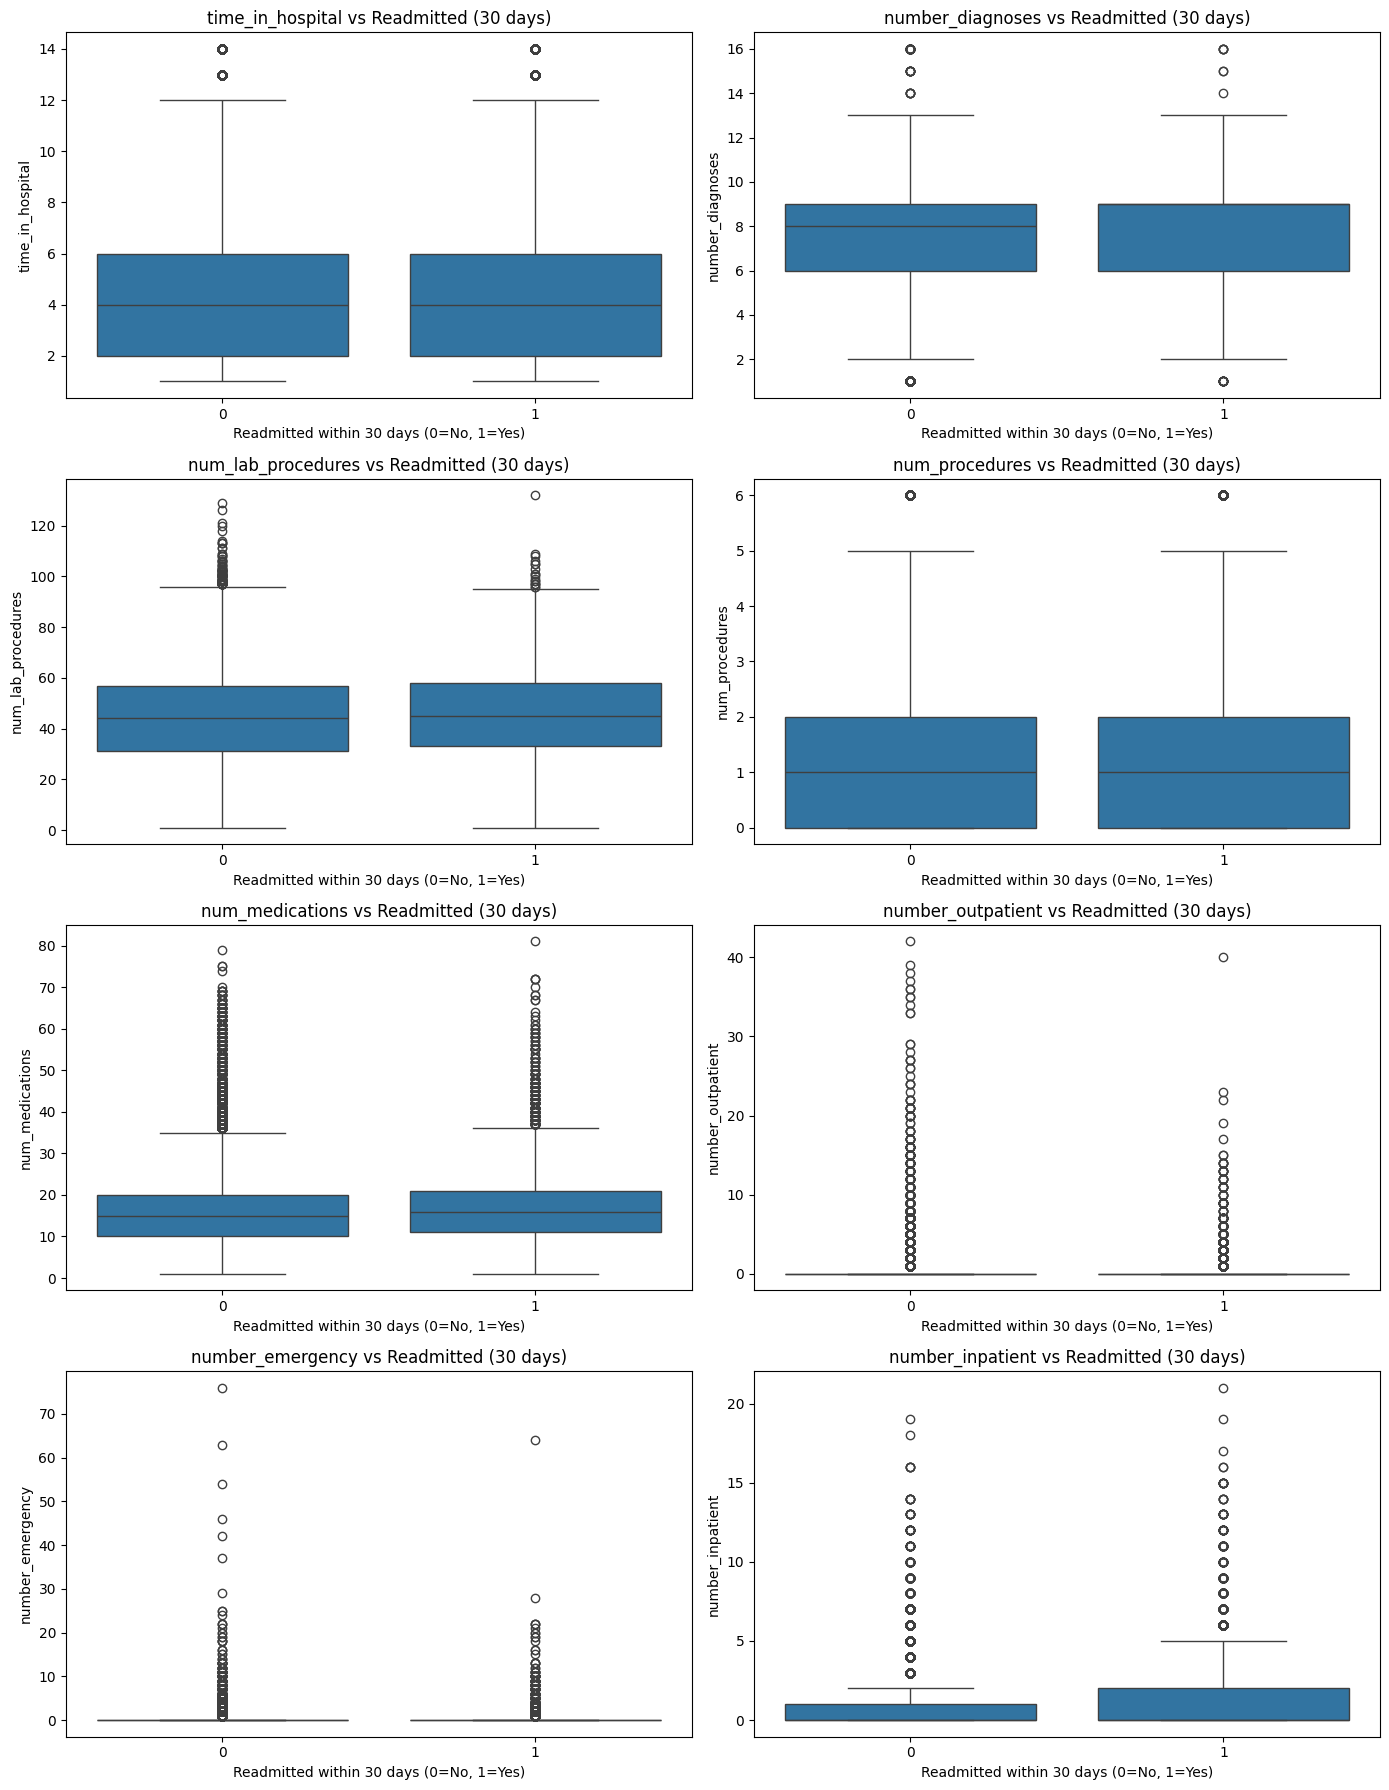

Mean values by readmission status:
                    Not Readmitted (0)  Readmitted <30d (1)  Difference
time_in_hospital              4.329437             4.767545    0.438108
number_diagnoses              7.364425             7.691798    0.327372
num_lab_procedures           42.737893            44.222114    1.484221
num_procedures                1.340854             1.282747   -0.058107
num_medications              15.859558            16.908874    1.049316
number_outpatient             0.360552             0.436892    0.076341
number_emergency              0.177975             0.357698    0.179723
number_inpatient              0.554874             1.222733    0.667859


In [ ]:
# Bivariate Analysis — Numeric Features vs. Target
numeric_cols = ['time_in_hospital', 'number_diagnoses', 'num_lab_procedures',
                 'num_procedures', 'num_medications', 'number_outpatient',
                 'number_emergency', 'number_inpatient']

# Boxplots: distribution of each numeric feature by readmission status
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='readmitted_30d', y=col, data=df_clean, ax=axes[i])
    axes[i].set_title(f'{col} vs Readmitted (30 days)')
    axes[i].set_xlabel('Readmitted within 30 days (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

# Mean comparison table
print("Mean values by readmission status:")
mean_comparison = df_clean.groupby('readmitted_30d')[numeric_cols].mean().T
mean_comparison.columns = ['Not Readmitted (0)', 'Readmitted <30d (1)']
mean_comparison['Difference'] = mean_comparison['Readmitted <30d (1)'] - mean_comparison['Not Readmitted (0)']
print(mean_comparison)

The bivariate analysis shows that patients who were **readmitted within 30 days** generally had **slightly longer hospital stays, more recorded diagnoses, more laboratory procedures, and higher medication usage** compared with patients who were not readmitted.

The strongest difference appears in **number_inpatient**, where readmitted patients had **substantially higher previous inpatient utilization** (mean ≈ **1.22** vs **0.55**). **number_emergency** also shows a noticeable increase among readmitted patients.

In contrast, **num_procedures** shows very little difference between the two groups. Overall, previous healthcare utilization, medication burden, and hospital stay duration appear to be **more informative indicators of 30-day readmission risk** than the number of procedures performed during the admission.


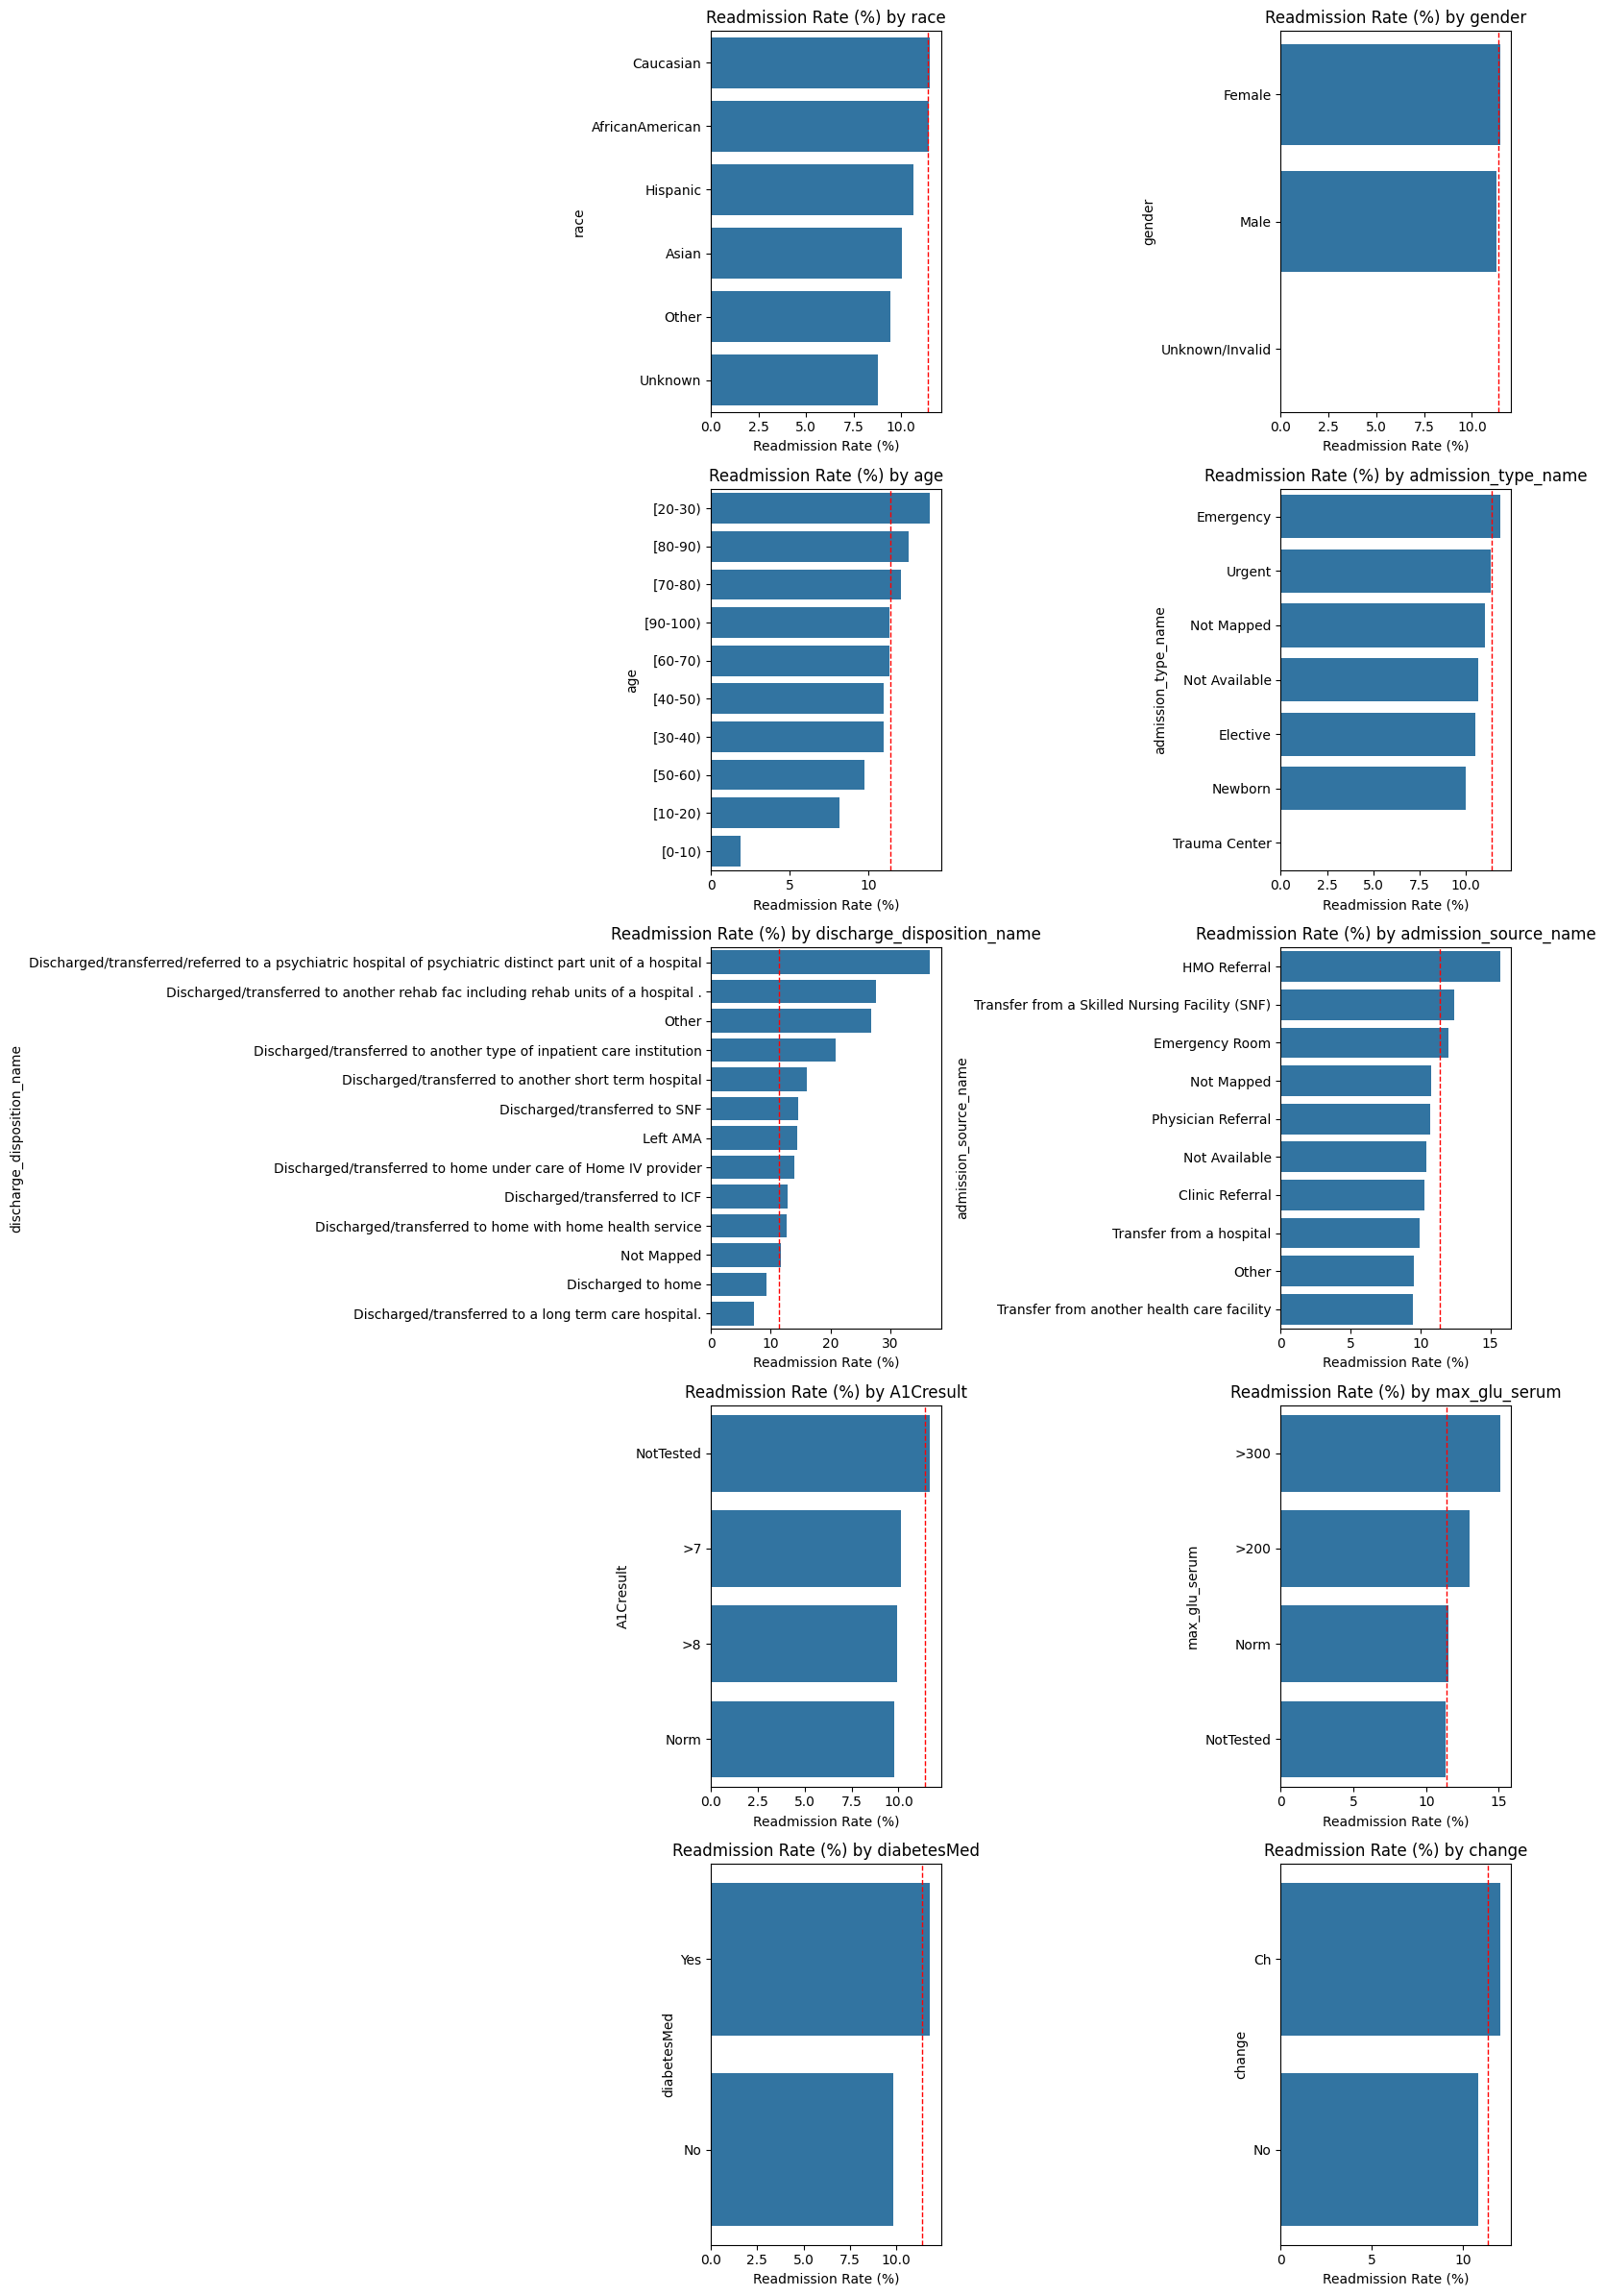

In [ ]:
# Bivariate Analysis — Categorical Features vs. Target
categorical_cols = ['race', 'gender', 'age', 'admission_type_name',
                     'discharge_disposition_name', 'admission_source_name',
                     'A1Cresult', 'max_glu_serum', 'diabetesMed', 'change']

fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate readmission RATE (%) per category, not just raw counts
    rate = df_clean.groupby(col)['readmitted_30d'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=axes[i])
    axes[i].set_title(f'Readmission Rate (%) by {col}')
    axes[i].set_xlabel('Readmission Rate (%)')
    axes[i].axvline(df_clean['readmitted_30d'].mean()*100, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

The categorical bivariate analysis shows that **emergency admissions, transfers from skilled nursing facilities, and several non-home discharge dispositions have higher-than-average 30-day readmission rates**. Older age groups also tend to show elevated readmission risk. Laboratory-related categories with **high serum glucose values** demonstrate increased readmission rates, while patients receiving **diabetes medication** or experiencing a **medication change during hospitalization** show slightly higher readmission rates than their respective comparison groups. Overall, **admission pathway, discharge disposition, prior care setting, and treatment-related factors appear to have stronger associations with 30-day readmission than demographic variables such as gender or race.**


## 4. FEATURE ENGINEERING
### 4.1. ICD-9 DIAGNOSIS CODE GROUPING

In [ ]:
def map_icd9_to_category(code):
    """
    Groups ICD-9 diagnosis codes into broader clinical categories,
    following the standard categorization used in Strack et al. (2014),
    the original research paper associated with this dataset.
    """
    if code == 'Unknown':
        return 'Unknown'
    code = str(code)

    if code.startswith('V'):
        return 'Supplemental (V-codes)'
    if code.startswith('E'):
        return 'External Causes (E-codes)'

    try:
        num = float(code)
    except ValueError:
        return 'Other'

    if 250 <= num < 251:
        return 'Diabetes'
    elif (390 <= num <= 459) or num == 785:
        return 'Circulatory'
    elif (460 <= num <= 519) or num == 786:
        return 'Respiratory'
    elif (520 <= num <= 579) or num == 787:
        return 'Digestive'
    elif 800 <= num <= 999:
        return 'Injury'
    elif 710 <= num <= 739:
        return 'Musculoskeletal'
    elif (580 <= num <= 629) or num == 788:
        return 'Genitourinary'
    elif 140 <= num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

# Apply to all three diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col + '_category'] = df_clean[col].apply(map_icd9_to_category)

# Verify
for col in ['diag_1_category', 'diag_2_category', 'diag_3_category']:
    print(f"\n===== {col} =====")
    print(df_clean[col].value_counts())

print("\nShape after adding diagnosis categories:", df_clean.shape)


===== diag_1_category =====
diag_1_category
Circulatory                  29681
Other                        16160
Respiratory                  13934
Digestive                     9333
Diabetes                      8661
Injury                        6853
Genitourinary                 5002
Musculoskeletal               4935
Neoplasms                     3131
Supplemental (V-codes)        1632
Unknown                         20
External Causes (E-codes)        1
Name: count, dtype: int64

===== diag_2_category =====
diag_2_category
Circulatory                  31158
Other                        23513
Diabetes                     12705
Respiratory                  10390
Genitourinary                 8147
Digestive                     4088
Injury                        2385
Neoplasms                     2326
Supplemental (V-codes)        1787
Musculoskeletal               1761
External Causes (E-codes)      727
Unknown                        356
Name: count, dtype: int64

===== diag_3_cate

In [ ]:
df_clean = df_clean.drop(columns=['diag_1', 'diag_2', 'diag_3'])
print("Shape after dropping raw diagnosis codes:", df_clean.shape)

Shape after dropping raw diagnosis codes: (99343, 34)


### 4.2. ORDINAL ENCODING

In [ ]:
# Age: clear order from youngest to oldest
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_map = {val: i for i, val in enumerate(age_order)}
df_clean['age_ordinal'] = df_clean['age'].map(age_map)

# A1Cresult: NotTested < Norm < >7 < >8 (blood sugar control severity)

a1c_map = {'NotTested': 0, 'Norm': 1, '>7': 2, '>8': 3}
df_clean['A1Cresult_ordinal'] = df_clean['A1Cresult'].map(a1c_map)

# max_glu_serum:
glu_map = {'NotTested': 0, 'Norm': 1, '>200': 2, '>300': 3}
df_clean['max_glu_serum_ordinal'] = df_clean['max_glu_serum'].map(glu_map)

# Medication columns: No < Steady < Down/Up (dosage change)
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = ['metformin', 'repaglinide', 'glimepiride', 'glipizide',
            'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
for col in med_cols:
    df_clean[col + '_ordinal'] = df_clean[col].map(med_map)

# Verify no missing values introduced
ordinal_cols = ['age_ordinal', 'A1Cresult_ordinal', 'max_glu_serum_ordinal'] + [c+'_ordinal' for c in med_cols]
print("Missing values check:")
print(df_clean[ordinal_cols].isnull().sum())
print("\nShape after ordinal encoding:", df_clean.shape)

Missing values check:
age_ordinal              0
A1Cresult_ordinal        0
max_glu_serum_ordinal    0
metformin_ordinal        0
repaglinide_ordinal      0
glimepiride_ordinal      0
glipizide_ordinal        0
glyburide_ordinal        0
pioglitazone_ordinal     0
rosiglitazone_ordinal    0
insulin_ordinal          0
dtype: int64

Shape after ordinal encoding: (99343, 45)


### 4.3. ONE-HOT ENCODING

In [ ]:
onehot_cols = ['race', 'gender', 'admission_type_name', 'discharge_disposition_name',
               'admission_source_name', 'medical_specialty', 'diag_1_category',
               'diag_2_category', 'diag_3_category', 'diabetesMed', 'change']

df_encoded = pd.get_dummies(df_clean, columns=onehot_cols, drop_first=True)

print("Shape after one-hot encoding:", df_encoded.shape)
print("\nSample of new columns:")
print([c for c in df_encoded.columns if 'race_' in c or 'gender_' in c])

Shape after one-hot encoding: (99343, 132)

Sample of new columns:
['race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_Unknown', 'gender_Male', 'gender_Unknown/Invalid']


In [ ]:
# Drop original text columns now that ordinal-encoded versions exist
original_ordinal_source_cols = ['age', 'A1Cresult', 'max_glu_serum',
                                 'metformin', 'repaglinide', 'glimepiride',
                                 'glipizide', 'glyburide', 'pioglitazone',
                                 'rosiglitazone', 'insulin']

df_encoded = df_encoded.drop(columns=original_ordinal_source_cols)

print("Shape after dropping original text columns:", df_encoded.shape)
print("\nRemaining non-numeric columns (should be minimal):")
print(df_encoded.select_dtypes(include='object').columns.tolist())

Shape after dropping original text columns: (99343, 121)

Remaining non-numeric columns (should be minimal):
['readmitted']


In [ ]:
# Convert boolean one-hot columns to integers
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Confirm identifier columns are NOT used as features
print("Bool columns converted:", len(bool_cols))
print("\nConfirming identifier columns still present (to be excluded before modeling):")
print(['encounter_id' in df_encoded.columns, 'patient_nbr' in df_encoded.columns])

print("\nFinal shape:", df_encoded.shape)
print(df_encoded.dtypes.value_counts())

Bool columns converted: 98

Confirming identifier columns still present (to be excluded before modeling):
[True, True]

Final shape: (99343, 121)
int64     120
object      1
Name: count, dtype: int64


In [ ]:
df_encoded

,encounter_id,patient_nbr,time_in_hospital,number_diagnoses,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_3_category_Genitourinary,diag_3_category_Injury,diag_3_category_Musculoskeletal,diag_3_category_Neoplasms,diag_3_category_Other,diag_3_category_Respiratory,diag_3_category_Supplemental (V-codes),diag_3_category_Unknown,diabetesMed_Yes,change_No
0,2278392,8222157,1,1,41,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,1
1,149190,55629189,3,9,59,0,18,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,64410,86047875,2,6,11,5,13,2,0,1,...,0,0,0,0,0,0,1,0,1,1
3,500364,82442376,2,7,44,1,16,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,16680,42519267,1,5,51,0,8,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99338,443847548,100162476,3,9,51,0,16,0,0,0,...,0,0,0,0,0,0,0,0,1,0
99339,443847782,74694222,5,9,33,3,18,0,0,1,...,0,0,0,0,0,0,0,0,1,1
99340,443854148,41088789,1,13,53,0,9,1,0,0,...,0,0,0,0,1,0,0,0,1,0
99341,443857166,31693671,10,9,45,2,21,0,0,1,...,0,1,0,0,0,0,0,0,1,0


In [ ]:
print(df_encoded.select_dtypes(include='object').columns.tolist())

['readmitted']


In [ ]:
# Dropping redundant target column (readmitted)
df_encoded = df_encoded.drop(columns=['readmitted'])

print("Final shape:", df_encoded.shape)
print("Remaining object columns:", df_encoded.select_dtypes(include='object').columns.tolist())
print(df_encoded.dtypes.value_counts())

Final shape: (99343, 120)
Remaining object columns: []
int64    120
Name: count, dtype: int64
